# Digit recognizer

## Description


In [1]:
# import necessary libraries

import warnings
warnings.filterwarnings("ignore")
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
%matplotlib inline



from keras.models import Sequential
from keras.layers import Dense , Dropout , Lambda, Flatten
from keras.optimizers import Adam ,RMSprop
from sklearn.model_selection import train_test_split
from keras import  backend as K
from keras.applications import VGG16
import tensorflow as tf





## Data collection

In [2]:
train_data = pd.read_csv('dataset/train.csv')
test_data = pd.read_csv('dataset/test.csv')
sample_submission = pd.read_csv('dataset/sample_submission.csv')


In [3]:
print(train_data.shape)
print(test_data.shape)
print(sample_submission.shape)

(42000, 785)
(28000, 784)
(28000, 2)


In [4]:
display(train_data.head(10))
display(test_data.head(10))
display(sample_submission.head(10)) 

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
5,6,0
6,7,0
7,8,0
8,9,0
9,10,0


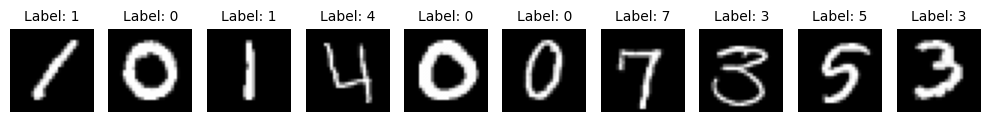

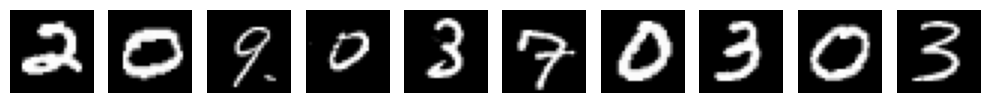

In [5]:
def show_images(df, num_images=10, start_index=0):
    """
    Display MNIST images from a DataFrame, with or without labels.

    Parameters:
    - df: pandas DataFrame. Can have a 'label' column or just pixel columns.
    - num_images: how many images to show.
    - start_index: which row to start from.
    """
    has_label = 'label' in df.columns
    pixel_cols = [col for col in df.columns if col.startswith('pixel')]
    
    plt.figure(figsize=(num_images, 2.5))

    for i in range(num_images):
        idx = start_index + i
        row = df.iloc[idx]

        pixels = row[pixel_cols].values
        if pixels.size != 784:
            print(f"⚠️ Skipping index {idx}: got {pixels.size} pixels instead of 784")
            continue

        image = pixels.reshape(28, 28)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image, cmap='gray')
        if has_label:
            plt.title(f"Label: {row['label']}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()




show_images(train_data, num_images=10)
show_images(test_data, num_images=10)



In [6]:
Images = train_data.iloc[:, 1:].values
Images = Images.reshape(Images.shape[0], 28, 28, 1)
Images = Images.astype('float32')
Images /= 255.0
Labels = train_data.iloc[:, 0].values
X_train, X_val, y_train, y_val = train_test_split(Images, Labels, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_val.shape)

def create_model():
    model = Sequential()
    model.add(Lambda(lambda x: tf.expand_dims(x, axis=-1), input_shape=(28, 28)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    
    return model
model = create_model()

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))



(33600, 28, 28, 1)
(8400, 28, 28, 1)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7744 - loss: 0.7138 - val_accuracy: 0.9461 - val_loss: 0.1767
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9375 - loss: 0.2076 - val_accuracy: 0.9548 - val_loss: 0.1463
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9518 - loss: 0.1597 - val_accuracy: 0.9631 - val_loss: 0.1227
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9647 - loss: 0.1199 - val_accuracy: 0.9661 - val_loss: 0.1097
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9671 - loss: 0.1072 - val_accuracy: 0.9692 - val_loss: 0.1031
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9708 - loss: 0.0932 - val_accuracy: 0.9713 - val_loss: 0.0972
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9741 - loss: 0.0800 - val_accuracy: 0.9720 - val_loss: 0.0964
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

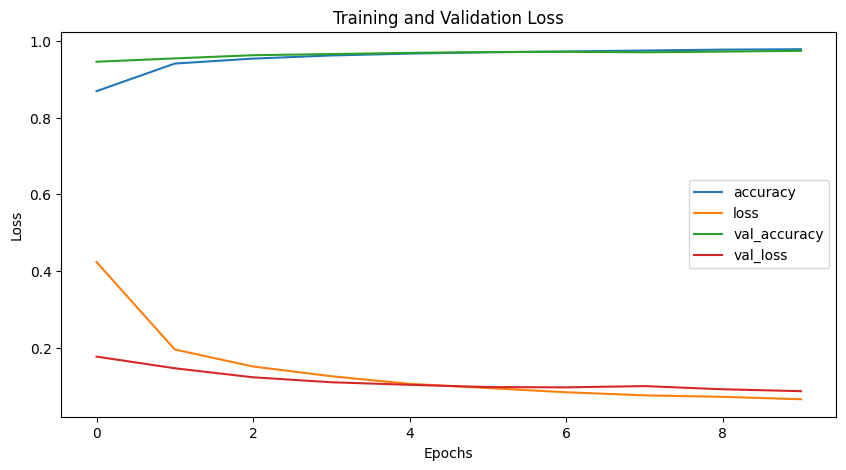

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step
Submission file created successfully!


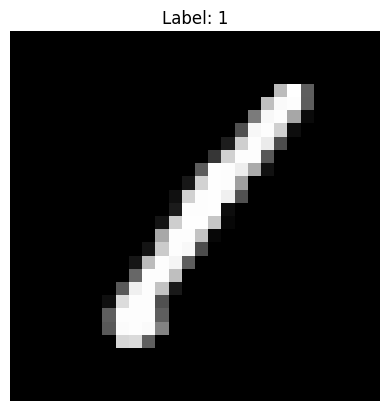

In [8]:
history_df = pd.DataFrame(history.history)
history_df.plot(figsize=(10, 5))
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
# Predict on test data
test_images = test_data.values.reshape(test_data.shape[0], 28, 28, 1)
test_images = test_images.astype('float32')

test_images /= 255.0
predictions = model.predict(test_images)        

predicted_labels = np.argmax(predictions, axis=1)

submission = pd.DataFrame({'ImageId': np.arange(1, len(predicted_labels) + 1), 'Label': predicted_labels})
submission.to_csv('submission.csv', index=False)
print("Submission file created successfully!")
# Display the first image from the training set
first_image = train_data.iloc[0, 1:].values.reshape(28, 28)
plt.imshow(first_image, cmap='gray')
plt.title(f"Label: {train_data.iloc[0]['label']}")
plt.axis('off')
plt.show()
